This page is dedicated to compare single-chain MCMC and multi-chain MCMC

In [1]:
!pip uninstall -yq jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt tensorflow-probability
# heads out since jax might drop support for cuda 12, currently (as of Aug 10, 2026), JAX has issues with CUDA 13
# see this post: https://github.com/jax-ml/jax/issues/37923
!pip install -Uq "jax[cuda12]" tfp-nightly blackjax inference_gym optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.9/184.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 9.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow-probability>=0.13.0, which is not installed.


In [ ]:
# run those checks if package compatibility is in trouble

# import jax
# import tensorflow_probability as tfp
# import jaxlib

# print("jaxlib:", jaxlib.__version__)
# print("TFP:", tfp.__version__)

# !pip show jax
# !pip show jaxlib
# !pip show blackjax

# import jax.numpy as jnp

# import blackjax

# import tensorflow_probability.substrates.jax as tfp
# import inference_gym.using_jax as gym

# print("JAX:", jax.__version__)
# print("BlackJAX:", blackjax.__version__)
# print("TFP:", tfp.__version__)
# print("ArviZ:", avs.__version__)
# print("Inference Gym imported successfully!")

**Package Import and other Setups**

In [1]:
# GPU set up to accelerate performance
import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random, jit, vmap, lax
import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions
import inference_gym.using_jax as gym
import jaxlib
import blackjax

import optax

# import arviz as az
# import arviz_stats as avs

import warnings
warnings.filterwarnings('ignore')

import psutil

import gc

from google.colab import drive
from matplotlib.lines import Line2D

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

# verification to make sure this is on a GPU
print(jax.devices())
print(jax.default_backend())

[CudaDevice(id=0)]
gpu


In [ ]:
drive.mount('/content/drive')
utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/Comparison_Utility.py'
with open(utility_link) as f: exec(f.read())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Hyperparameter Setups**

In [48]:
# max_warmup = 1000
# warmup_window = 100

# window_array = np.append(np.repeat(10, 10),
#                       np.repeat(warmup_window, max_warmup // warmup_window - 1))

# warmup_length = np.repeat(10, len(window_array))
# for i in range(len(warmup_length) - 1):
#     warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# reduce the chain number for better visual
num_chains_short = 512
num_super_chains = 4

In [49]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains # 128
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

**Single Chain MCMC**

In [6]:
target = gym.targets.VectorModel(
    gym.targets.Banana(),
    flatten_sample_transformations=True
)

num_dimensions = target.event_shape[0]

# print("Target:", type(target))
# print("Dimensions:", num_dimensions)
# print("Event shape:", target.event_shape)
# Get some estimates of the mean and variance.
try:
  mean_est = target.sample_transformations['identity'].ground_truth_mean
except:
  print('no ground truth mean')
  mean_est = (result.all_states[num_warmup:, :]).mean(0).mean(0)
try:
  var_est = target.sample_transformations['identity'].ground_truth_standard_deviation**2
except:
  print('no ground truth std dev')
  var_est = ((result.all_states[num_warmup:, :]**2).mean(0).mean(0) -
             mean_est**2)
mean_benchmark = mean_est
var_benchmark = var_est

In [7]:
def logdensity(x):
    y = target.default_event_space_bijector(x)
    fldj = target.default_event_space_bijector.forward_log_det_jacobian(x)
    return target.unnormalized_log_prob(y) + fldj
offset = 2.0
initial_step_size = 1.
def initialize(shape, key):
    return (10 * random.normal(key, shape+(num_dimensions,))+ offset)

**Sampling Phase**

In [8]:
warmup_length = 100

In [50]:
# single chain run with 2048 iterations
samples, mean_r_hat, mean_mse = multiple_chains(warmup_length, num_chains_short,initialize, random.PRNGKey(1),
                    logdensity, initial_step_size, [], 1,mean_benchmark,var_benchmark)

In [51]:
# multiple chain ran consecutively
multichain_samples, multichain_mean_r_hat, multichain_mean_mse = multiple_chains(warmup_length, M,initialize, random.PRNGKey(1),
                    logdensity, initial_step_size, [], num_super_chains,mean_benchmark,var_benchmark)

In [52]:
# constrained initalization of many-short-chain:
constrained_sample, constrained_rhat, constrained_mse = simulation(warmup_length,num_chains_short, num_super_chains,
               False,initialize, random.PRNGKey(1),
               logdensity,initial_step_size,
               mean_benchmark,var_benchmark)

In [53]:
naive_sample, naive_rhat, naive_mse = simulation(warmup_length,num_chains_short, num_super_chains,
               True,initialize, random.PRNGKey(1),
               logdensity,initial_step_size,
               mean_benchmark, var_benchmark)

In [54]:
samples[0]["Samples"].shape[0]

512

**Plot**

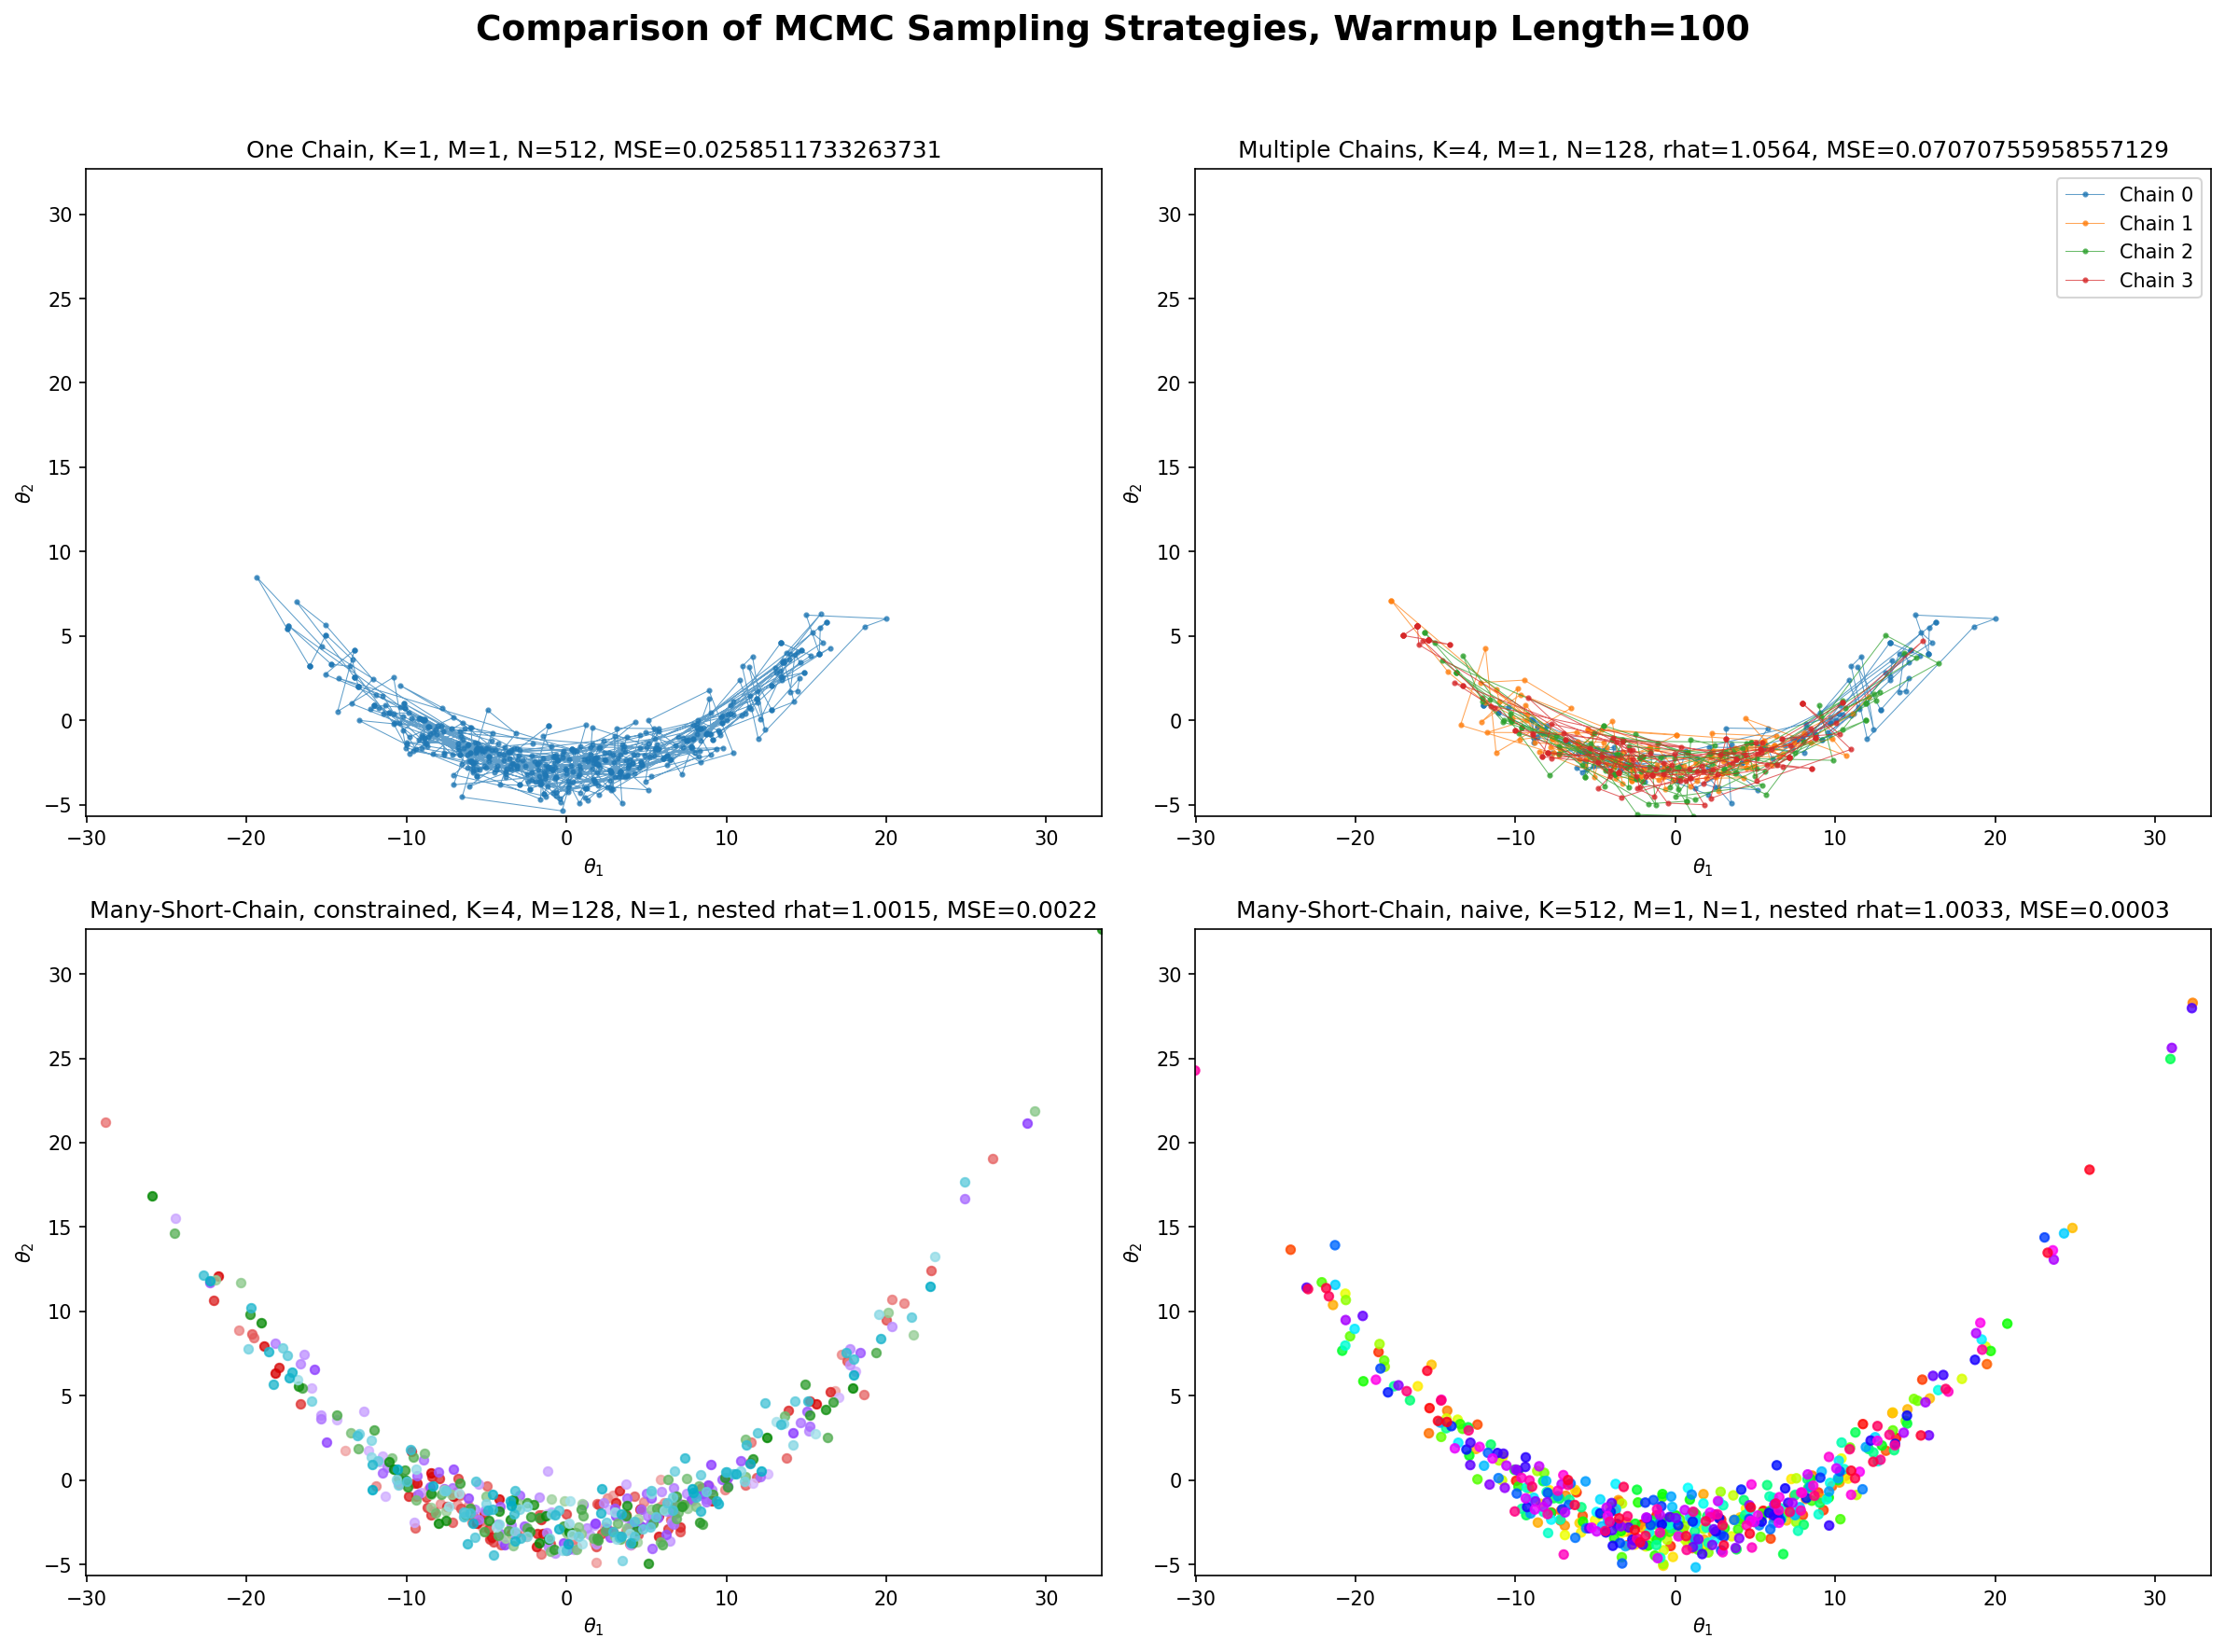

In [55]:
params = (num_super_chains, M,num_chains_short, warmup_length)
comparison_plot(params,
                samples, mean_mse,
                multichain_samples, multichain_mean_mse,multichain_mean_r_hat,
                constrained_sample, constrained_mse,constrained_rhat,
                naive_sample, naive_mse, naive_rhat)